In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb

In [48]:
dev_path='Dev_data_to_be_shared.csv'
df=pd.read_csv(dev_path)

In [49]:
df.head(5)

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
df.columns

Index(['account_number', 'bad_flag', 'onus_attribute_1',
       'transaction_attribute_1', 'transaction_attribute_2',
       'transaction_attribute_3', 'transaction_attribute_4',
       'transaction_attribute_5', 'transaction_attribute_6',
       'transaction_attribute_7',
       ...
       'bureau_enquiry_47', 'bureau_enquiry_48', 'bureau_enquiry_49',
       'bureau_enquiry_50', 'onus_attribute_43', 'onus_attribute_44',
       'onus_attribute_45', 'onus_attribute_46', 'onus_attribute_47',
       'onus_attribute_48'],
      dtype='object', length=1216)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96806 entries, 0 to 96805
Columns: 1216 entries, account_number to onus_attribute_48
dtypes: float64(1189), int64(27)
memory usage: 898.1 MB


In [52]:
df.describe()

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
count,96806.000000,96806.000000,7.157500e+04,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,...,94212.0,94212.000000,94212.000000,94212.000000,11610.000000,11610.000000,11610.000000,11610.000000,11610.000000,11610.000000
mean,48403.500000,0.014173,1.542391e+05,9.570769,0.002207,4.092854,77.306435,0.006315,67.043550,0.081034,...,0.0,0.189657,0.044283,7.800673,0.588114,1.497158,0.545650,1.430491,0.121447,0.119208
std,27945.629417,0.118203,1.729925e+05,1513.967595,0.119240,301.580599,3164.987013,0.129545,2516.330899,14.203615,...,0.0,0.597298,0.369451,8.655149,1.059613,1.702795,1.055865,1.728950,0.601256,0.599697
min,1.000000,0.000000,2.500000e+04,0.000000,0.000000,0.000000,-109800.476600,0.000000,-3498.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24202.250000,0.000000,5.900000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,48403.500000,0.000000,1.000000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,5.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,72604.750000,0.000000,1.810000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,11.000000,1.000000,2.000000,1.000000,2.000000,0.000000,0.000000
max,96806.000000,1.000000,2.800000e+06,398936.791000,25.000000,55000.000000,358986.000000,12.000000,358986.000000,3150.000000,...,0.0,18.000000,14.000000,102.000000,19.000000,38.000000,19.000000,38.000000,15.000000,15.000000


In [53]:
df.isnull().sum()

account_number                 0
bad_flag                       0
onus_attribute_1           25231
transaction_attribute_1    25231
transaction_attribute_2    25231
                           ...  
onus_attribute_44          85196
onus_attribute_45          85196
onus_attribute_46          85196
onus_attribute_47          85196
onus_attribute_48          85196
Length: 1216, dtype: int64

In [54]:
df.fillna(0, inplace=True)
df.isnull().sum()

account_number             0
bad_flag                   0
onus_attribute_1           0
transaction_attribute_1    0
transaction_attribute_2    0
                          ..
onus_attribute_44          0
onus_attribute_45          0
onus_attribute_46          0
onus_attribute_47          0
onus_attribute_48          0
Length: 1216, dtype: int64

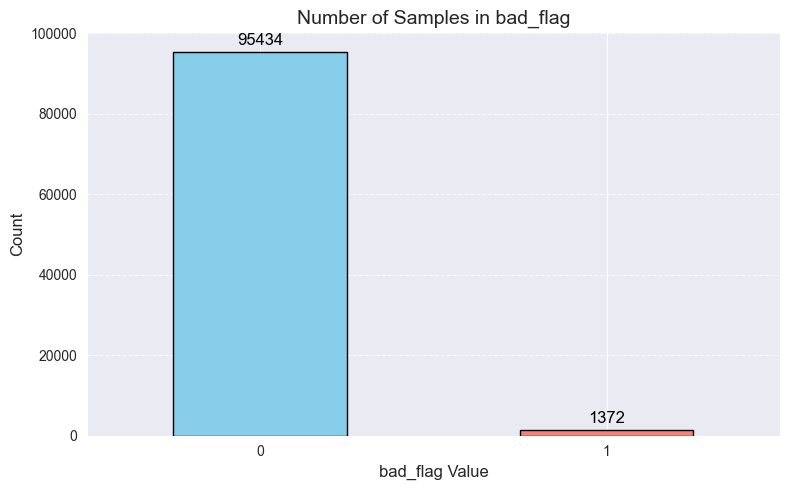

In [55]:
# Count the number of samples for each value in bad_flag
bad_flag_counts = df['bad_flag'].value_counts()

# Plot the counts
plt.figure(figsize=(8, 5))
bars = bad_flag_counts.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')

# Add counts on top of the bars
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate
        height + 0.01 * max(bad_flag_counts),  # Y-coordinate
        f'{int(height)}',  # Text to display
        ha='center', va='bottom', fontsize=12, color='black'
    )

# Customize the plot
plt.title('Number of Samples in bad_flag', fontsize=14)
plt.xlabel('bad_flag Value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

In [56]:
onus_columns = [col for col in df.columns if col.startswith("onus_attribute")]
transaction_columns = [col for col in df.columns if col.startswith("transaction_attribute")]

# Calculate the sum for each group
df["onus_sum"] = df[onus_columns].sum(axis=1)
df["transaction_sum"] = df[transaction_columns].sum(axis=1)

# Add a new column to check if the credit limit is exceeded
df["limit_exceeded"] = (df["onus_sum"] < df["transaction_sum"]).astype('int64')
df.drop(["onus_sum", "transaction_sum"], axis=1, inplace=True)

df.head(5)

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48,limit_exceeded
0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96806 entries, 0 to 96805
Columns: 1217 entries, account_number to limit_exceeded
dtypes: float64(1189), int64(28)
memory usage: 898.8 MB


In [58]:
selected_cols = [col for col in df.columns if col.startswith(('onus_attribute','transaction_attribute', 'bureau', 'bureau_enquiry'))]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Copy the original DataFrame to preserve the original data
df_normalized = df.copy()

# Normalize the selected columns
df_normalized[selected_cols] = scaler.fit_transform(df[selected_cols])

print(f"Normalization completed on the following columns: {selected_cols}")

Normalization completed on the following columns: ['onus_attribute_1', 'transaction_attribute_1', 'transaction_attribute_2', 'transaction_attribute_3', 'transaction_attribute_4', 'transaction_attribute_5', 'transaction_attribute_6', 'transaction_attribute_7', 'transaction_attribute_8', 'transaction_attribute_9', 'transaction_attribute_10', 'transaction_attribute_11', 'transaction_attribute_12', 'transaction_attribute_13', 'transaction_attribute_14', 'transaction_attribute_15', 'transaction_attribute_16', 'transaction_attribute_17', 'transaction_attribute_18', 'transaction_attribute_19', 'transaction_attribute_20', 'transaction_attribute_21', 'transaction_attribute_22', 'transaction_attribute_23', 'transaction_attribute_24', 'transaction_attribute_25', 'transaction_attribute_26', 'transaction_attribute_27', 'transaction_attribute_28', 'transaction_attribute_29', 'transaction_attribute_30', 'transaction_attribute_31', 'transaction_attribute_32', 'transaction_attribute_33', 'transaction_a

In [59]:
df_normalized.describe()

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48,limit_exceeded
count,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,...,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000
mean,48403.500000,0.014173,0.040728,0.000018,0.000065,0.000055,0.234345,0.000389,0.009787,0.000019,...,0.010254,0.003078,0.074428,0.003712,0.004725,0.003444,0.004515,0.000971,0.000953,0.757236
std,27945.629417,0.118203,0.058370,0.003263,0.004101,0.004715,0.005806,0.009285,0.005970,0.003877,...,0.032780,0.026038,0.084616,0.021774,0.020116,0.021387,0.019946,0.014128,0.014084,0.428756
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24202.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.000000,0.000000,0.009804,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,48403.500000,0.000000,0.024643,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.000000,0.000000,0.049020,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,72604.750000,0.000000,0.051786,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.000000,0.000000,0.107843,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,96806.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


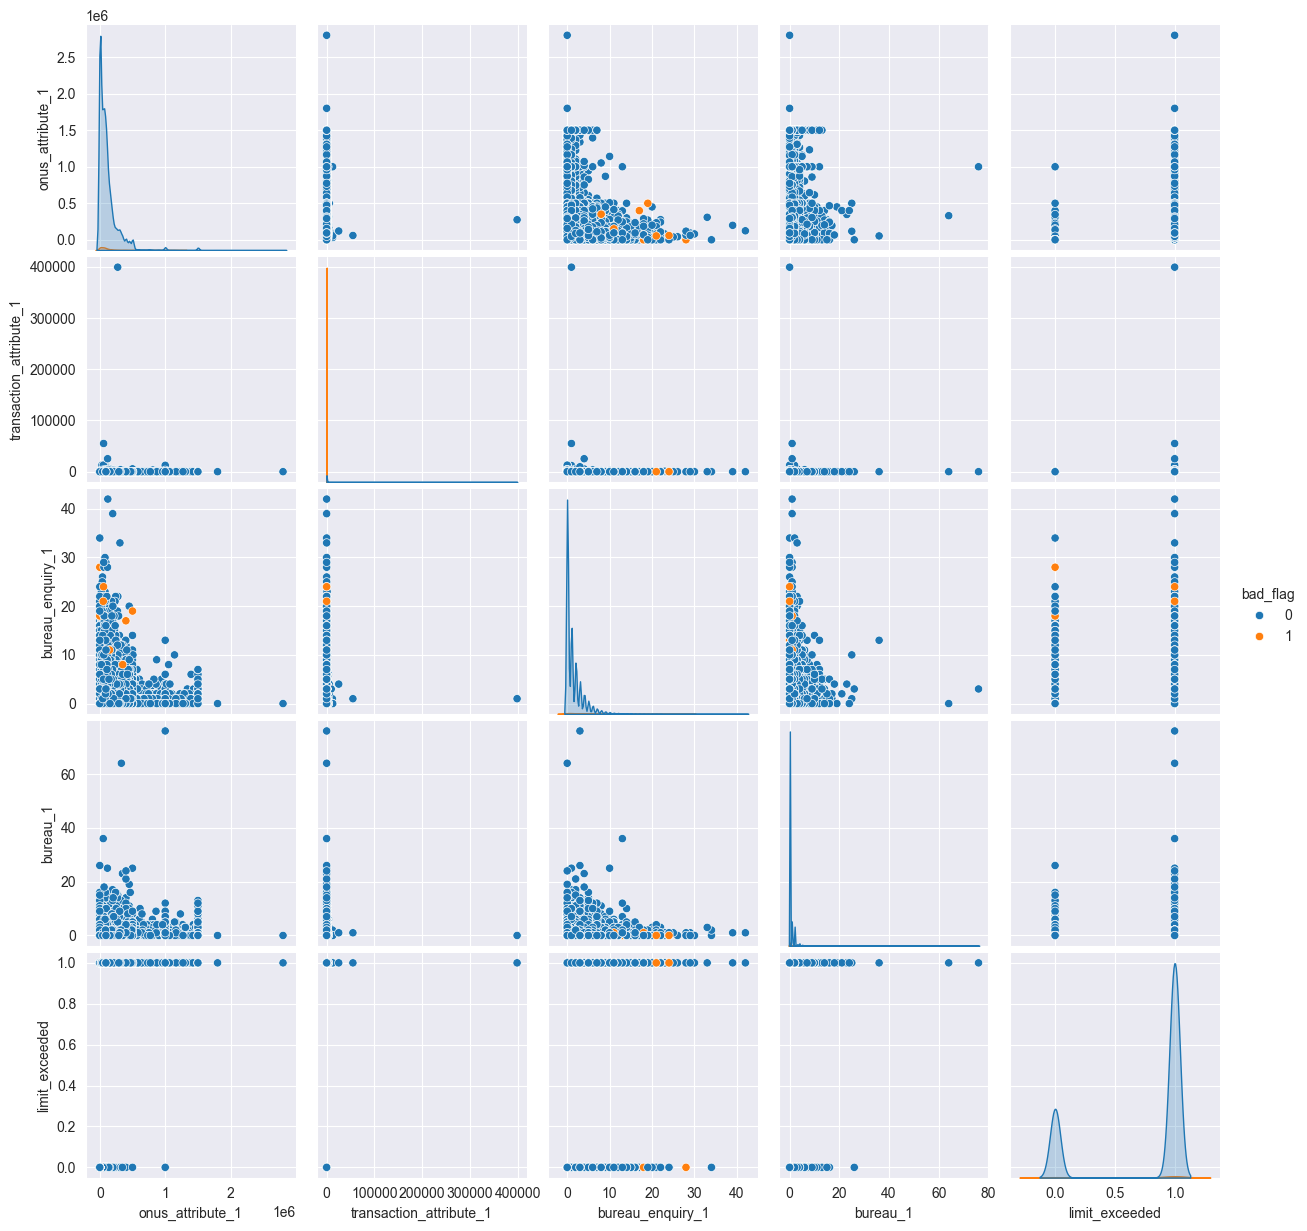

In [68]:
selected_columns = ['onus_attribute_1', 'transaction_attribute_1', 'bureau_enquiry_1', 'bureau_1', 'limit_exceeded']

# Create the pairplot
sns.pairplot(df[selected_columns + ['bad_flag']], hue='bad_flag')

# Show the plot
plt.show()

In [61]:
# Extract features (X) and target (y) from df_normalized
X = df_normalized.drop(columns=['account_number','bad_flag'])
y = df_normalized['bad_flag']

# Initialize the undersampler
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=12)

# Apply undersampling to balance the dataset
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Combine the resampled features and target into a new dataframe
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='bad_flag')], axis=1)

# Check the distribution of the classes in the resampled dataset
print("Resampled class distribution after UnderSampler:")
print(df_resampled['bad_flag'].value_counts())

Resampled class distribution after UnderSampler:
bad_flag
0    2744
1    1372
Name: count, dtype: int64


In [62]:
X_resampled = df_resampled.drop(columns=['bad_flag'])
y_resampled = df_resampled['bad_flag']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=12)

# Check the shape of the resulting splits
print(f"Training Data Features: {X_train.shape}")
print(f"Testing Data Features: {X_test.shape}")
print(f"Training Data Target: {y_train.shape}")
print(f"Testing Data Target: {y_test.shape}")


Training Data Features: (3292, 1215)
Testing Data Features: (824, 1215)
Training Data Target: (3292,)
Testing Data Target: (824,)


In [63]:
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=12, max_iter=2000, class_weight='balanced', solver='liblinear')

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_prob = log_reg_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (1)

In [64]:
# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Accuracy Score: 0.7402912621359223
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       559
           1       0.57      0.77      0.66       265

    accuracy                           0.74       824
   macro avg       0.72      0.75      0.72       824
weighted avg       0.77      0.74      0.75       824

ROC-AUC Score: 0.8287845546292234


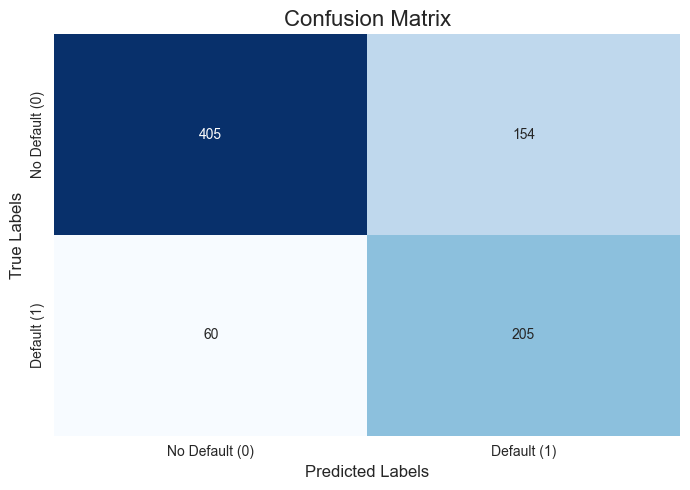

In [65]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()

plt.show()

In [66]:
# from sklearn.model_selection import GridSearchCV, StratifiedKFold
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
#
# # Scale the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
#
# # Define the model
# log_reg_model = LogisticRegression(random_state=97)
#
# # Define the hyperparameters to tune
# param_grid = {
#     'C': [0.01, 0.1, 1, 10, 100],
#     'solver': ['liblinear', 'newton-cg', 'lbfgs', 'saga'],
#     'max_iter': [300, 500, 1000, 2500, 5000],
#     'penalty': ['l2', 'elasticnet'],
#     'class_weight': ['balanced', None],
#     'tol': [1e-4, 1e-3, 1e-2],
#     'intercept_scaling': [1, 10, 100]  # for liblinear solver
# }
#
# # Initialize GridSearchCV
# grid_search = GridSearchCV(estimator=log_reg_model, param_grid=param_grid, cv=StratifiedKFold(n_splits=5), scoring='accuracy', n_jobs=-1, verbose=2)
#
# # Fit the model
# grid_search.fit(X_train_scaled, y_train)
#
# # Best parameters found by GridSearchCV
# print("Best Hyperparameters:")
# print(grid_search.best_params_)
#
# # Best score
# print("Best Cross-validation Accuracy: {:.4f}".format(grid_search.best_score_))
#
# # Evaluate the best model on the test set
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test_scaled)
# y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]
#
# # Accuracy score
# print("Accuracy Score:", accuracy_score(y_test, y_pred))
#
# # Confusion Matrix
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))
#
# # Classification Report
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))
#
# # ROC-AUC Score
# print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Accuracy Score: 0.7402912621359223

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       559
           1       0.57      0.77      0.66       265

    accuracy                           0.74       824
   macro avg       0.72      0.75      0.72       824
weighted avg       0.77      0.74      0.75       824


ROC-AUC Score: 0.8287575522327606


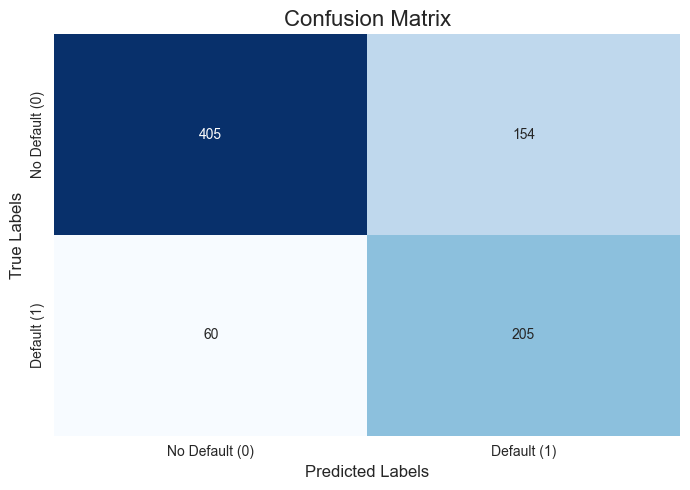

In [67]:
# Define the Logistic Regression model with the best hyperparameters
final_model = LogisticRegression(
    C=1,
    solver='newton-cg',
    penalty='l2',
    max_iter=1000,
    class_weight='balanced',
    random_state=97
)

# Fit the model to the training data
final_model.fit(X_train, y_train)

# Evaluate the model
y_pred = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()


In [73]:
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Accuracy Score: 0.7645631067961165

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       559
           1       0.62      0.68      0.65       265

    accuracy                           0.76       824
   macro avg       0.73      0.74      0.74       824
weighted avg       0.77      0.76      0.77       824


Confusion Matrix:
[[450 109]
 [ 85 180]]

ROC-AUC Score: 0.8182468694096602


In [76]:
# Get feature importances from the trained XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a DataFrame to pair feature names with their importance values
features = X_train.columns
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
1119,onus_attribute_4,0.020081
1141,onus_attribute_26,0.019843
765,bureau_101,0.012622
537,transaction_attribute_537,0.011663
431,transaction_attribute_431,0.011556
...,...,...
458,transaction_attribute_458,0.000000
459,transaction_attribute_459,0.000000
460,transaction_attribute_460,0.000000
461,transaction_attribute_461,0.000000


In [98]:
# Define the hyperparameters grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=12,scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=3,
                           n_jobs=-1,
                           verbose=2)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Best parameters and score from grid search
print("Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)
print("Best Cross-validation Accuracy: {:.4f}".format(grid_search.best_score_))

# Evaluate the best model on the test set
best_xgb_model = grid_search.best_estimator_
y_pred = best_xgb_model.predict(X_test)
y_pred_prob = best_xgb_model.predict_proba(X_test)[:, 1]

# Display the evaluation metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Hyperparameters from GridSearchCV:
{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 500, 'subsample': 0.7}
Best Cross-validation Accuracy: 0.7625
Accuracy Score: 0.7621359223300971

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       559
           1       0.60      0.79      0.68       265

    accuracy                           0.76       824
   macro avg       0.74      0.77      0.75       824
weighted avg       0.79      0.76      0.77       824


Confusion Matrix:
[[418 141]
 [ 55 210]]

ROC-AUC Score: 0.8394640024302157


In [119]:
# # Define the XGBoost model with the best hyperparameters
# final_xgb_model = xgb.XGBClassifier(
#     n_estimators=500,
#     learning_rate=0.01,
#     max_depth=7,
#     min_child_weight=5,
#     subsample=0.7,
#     colsample_bytree=0.7,
#     objective="binary:logistic",
#     eval_metric="logloss",
#     random_state=12,
#     scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
# )
#
# # Fit the model to the training data
# final_xgb_model.fit(X_train, y_train)
#
# # Evaluate the model
# y_pred = final_xgb_model.predict(X_test)
# y_pred_prob = final_xgb_model.predict_proba(X_test)[:, 1]
#
# # Evaluation Metrics
# print("Accuracy Score:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))
# print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))
#
# cm2 = confusion_matrix(y_test, y_pred)
#
# # Plot the confusion matrix using seaborn heatmap
# plt.figure(figsize=(7, 5))
# sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
#             xticklabels=['No Default (0)', 'Default (1)'],
#             yticklabels=['No Default (0)', 'Default (1)'])
# plt.title('Confusion Matrix', fontsize=16)
# plt.xlabel('Predicted Labels', fontsize=12)
# plt.ylabel('True Labels', fontsize=12)
# plt.tight_layout()
# plt.show()

Accuracy Score: 0.7779126213592233

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       559
           1       0.63      0.76      0.69       265

    accuracy                           0.78       824
   macro avg       0.75      0.77      0.76       824
weighted avg       0.80      0.78      0.78       824


ROC-AUC Score: 0.8410503932223985


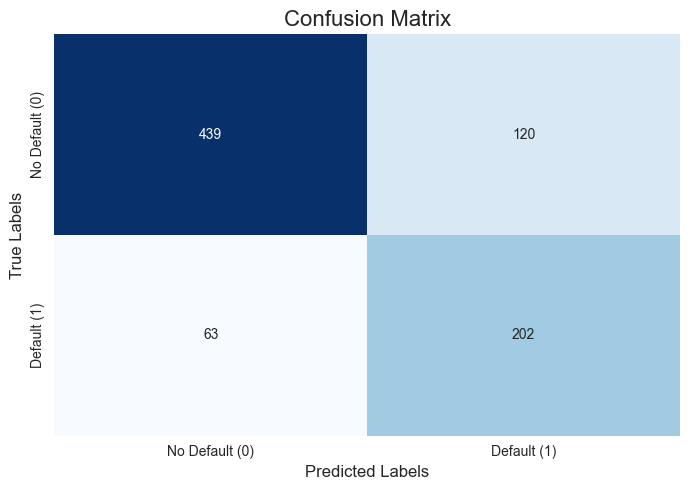

In [117]:
# Define the XGBoost model with the best hyperparameters
final_xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=12,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

# Fit the model to the training data
final_xgb_model.fit(X_train, y_train)

# Evaluate the model
y_pred = final_xgb_model.predict(X_test)
y_pred_prob = final_xgb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()